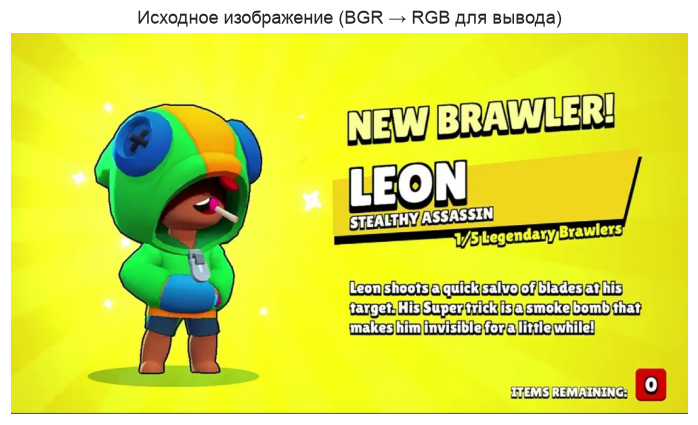

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

IMAGE_PATH = Path('../lab2/image.png')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {IMAGE_PATH.resolve()}')

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if image is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4.5))
plt.imshow(image_rgb)
plt.title('Исходное изображение (BGR → RGB для вывода)')
plt.axis('off')
plt.show()

In [2]:
height, width, channels = image.shape

print(f'Ширина           : {width} пикс.')
print(f'Высота           : {height} пикс.')
print(f'Число каналов    : {channels} (порядок BGR)')
print(f'Тип данных       : {image.dtype}')
print(f'Всего пикселей   : {height * width}')
print(f'Размер в памяти  : {image.nbytes / 1024 / 1024:.2f} МБ')
print()
print(f'Пиксель [0, 0]                : BGR = {image[0, 0]}')
print(f'Пиксель в центре [{height//2}, {width//2}] : BGR = {image[height // 2, width // 2]}')

Ширина           : 1000 пикс.
Высота           : 563 пикс.
Число каналов    : 3 (порядок BGR)
Тип данных       : uint8
Всего пикселей   : 563000
Размер в памяти  : 1.61 МБ

Пиксель [0, 0]                : BGR = [ 23 213 223]
Пиксель в центре [281, 500] : BGR = [ 39  93 102]


Полутоновое изображение: shape = (563, 1000), диапазон 0…255
Средняя яркость        : 196.24
Порог Оцу              : 142
Доля белых пикселей    : 85.00%


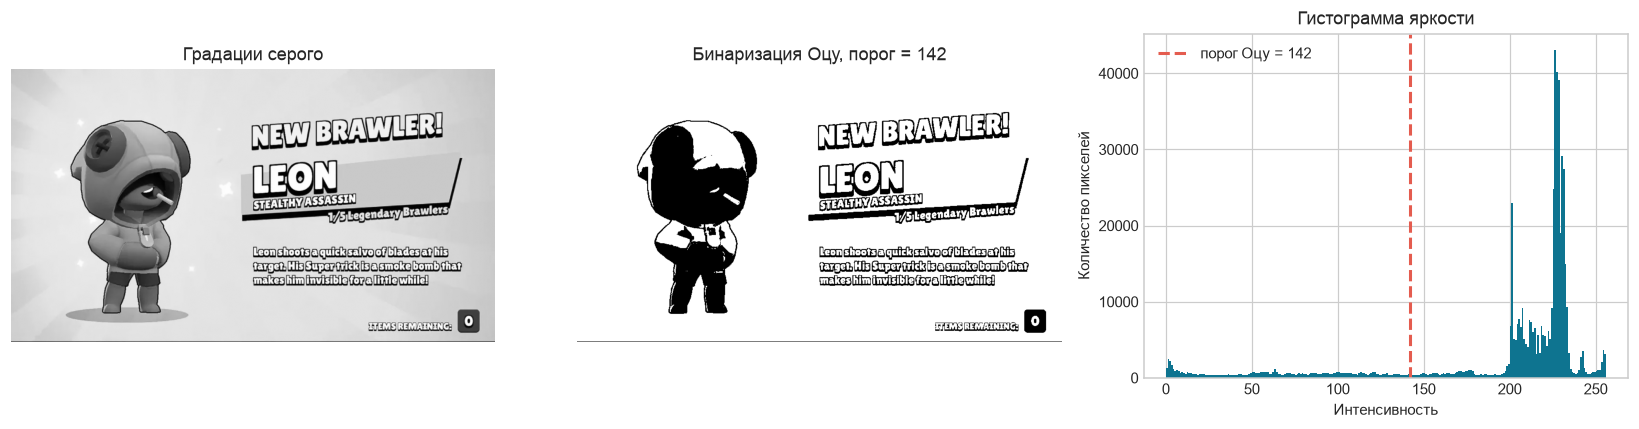

Сохранено: output/gray.png, output/otsu_binary.png


In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
otsu_threshold, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

white_ratio = float((binary == 255).mean())
print(f'Полутоновое изображение: shape = {gray.shape}, диапазон {gray.min()}…{gray.max()}')
print(f'Средняя яркость        : {gray.mean():.2f}')
print(f'Порог Оцу              : {otsu_threshold:.0f}')
print(f'Доля белых пикселей    : {white_ratio * 100:.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Градации серого')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Бинаризация Оцу, порог = {otsu_threshold:.0f}')
axes[2].hist(gray.ravel(), bins=256, range=(0, 256), color='#0e7490')
axes[2].axvline(otsu_threshold, color='#e45c4f', linestyle='--', linewidth=2,
                label=f'порог Оцу = {otsu_threshold:.0f}')
axes[2].set_title('Гистограмма яркости')
axes[2].set_xlabel('Интенсивность')
axes[2].set_ylabel('Количество пикселей')
axes[2].legend()
for ax in axes[:2]:
    ax.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / 'gray.png'), gray)
cv2.imwrite(str(OUTPUT_DIR / 'otsu_binary.png'), binary)
print('Сохранено: output/gray.png, output/otsu_binary.png')

H (тон)              диапазон значений 0…179 (теоретический 0…179), среднее 35.1
S (насыщенность)     диапазон значений 0…255 (теоретический 0…255), среднее 202.6
V (яркость)          диапазон значений 0…255 (теоретический 0…255), среднее 224.1


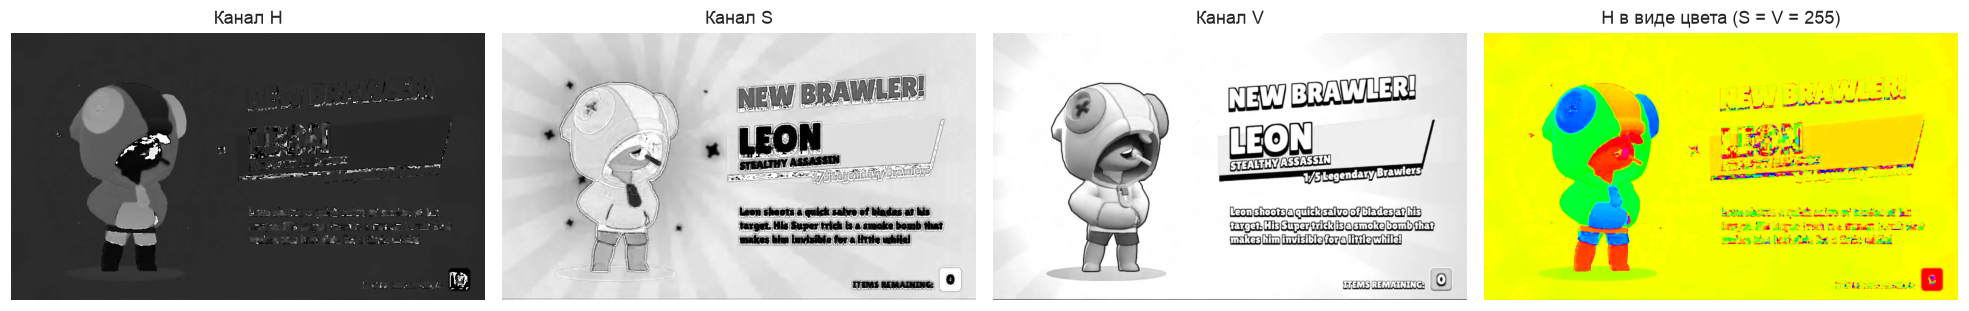

Сохранено: output/hsv_h.png, output/hsv_s.png, output/hsv_v.png


In [4]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

for name, channel, rng in (('H (тон)', h, '0…179'), ('S (насыщенность)', s, '0…255'), ('V (яркость)', v, '0…255')):
    print(f'{name:<20} диапазон значений {channel.min()}…{channel.max()} (теоретический {rng}), '
          f'среднее {channel.mean():.1f}')

hue_colored = cv2.cvtColor(cv2.merge([h, np.full_like(h, 255), np.full_like(h, 255)]), cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].imshow(h, cmap='gray'), axes[0].set_title('Канал H')
axes[1].imshow(s, cmap='gray'), axes[1].set_title('Канал S')
axes[2].imshow(v, cmap='gray'), axes[2].set_title('Канал V')
axes[3].imshow(hue_colored), axes[3].set_title('H в виде цвета (S = V = 255)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / 'hsv_h.png'), h)
cv2.imwrite(str(OUTPUT_DIR / 'hsv_s.png'), s)
cv2.imwrite(str(OUTPUT_DIR / 'hsv_v.png'), v)
print('Сохранено: output/hsv_h.png, output/hsv_s.png, output/hsv_v.png')

Ширина полосы          : 20 пикс.
Изменено пикселей      : 11260 (ожидалось 11260)
Проверка edited[0, 0]  : BGR = [255   0   0] → синий
Проверка edited[0, 20] : BGR = [ 20 219 225] → не изменён


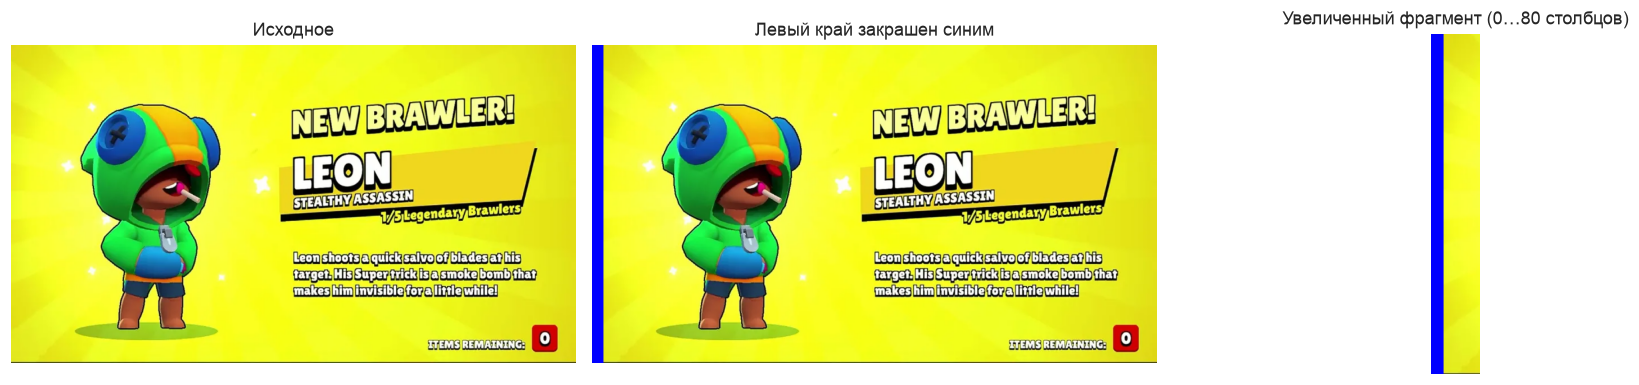

In [ ]:
EDGE_WIDTH = 20
BLUE_BGR = (255, 0, 0)

edited = image.copy()
edited[:, :EDGE_WIDTH] = BLUE_BGR

changed = int((edited != image).any(axis=2).sum())
print(f'Ширина полосы          : {EDGE_WIDTH} пикс.')
print(f'Изменено пикселей      : {changed} (ожидалось {height * EDGE_WIDTH})')
print(f'Проверка edited[0, 0]  : BGR = {edited[0, 0]} → синий')
print(f'Проверка edited[0, {EDGE_WIDTH}] : BGR = {edited[0, EDGE_WIDTH]} → не изменён')

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
axes[0].imshow(image_rgb), axes[0].set_title('Исходное')
axes[1].imshow(cv2.cvtColor(edited, cv2.COLOR_BGR2RGB)), axes[1].set_title('Левый край закрашен синим')
axes[2].imshow(cv2.cvtColor(edited[:, :80], cv2.COLOR_BGR2RGB)), axes[2].set_title('Увеличенный фрагмент (0…80 столбцов)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
saved_path = OUTPUT_DIR / 'edited_blue_edge.png'
ok = cv2.imwrite(str(saved_path), edited)
print(f'Запись выполнена: {ok}, файл: {saved_path} ({saved_path.stat().st_size / 1024:.1f} КБ)')

check = cv2.imread(str(saved_path), cv2.IMREAD_COLOR)
print(f'Файл прочитан обратно: shape = {check.shape}')
print(f'Совпадает с оригиналом в памяти: {np.array_equal(check, edited)}')
print(f'Цвет пикселя [10, 10] в файле  : BGR = {check[10, 10]}')

Запись выполнена: True, файл: output/edited_blue_edge.png (514.4 КБ)
Файл прочитан обратно: shape = (563, 1000, 3)
Совпадает с оригиналом в памяти: True
Цвет пикселя [10, 10] в файле  : BGR = [255   0   0]


Порог из OpenCV          : 142
Порог, посчитанный вручную: 142
Максимум σ_b²            : 3018.0
порог 100    доля белого = 88.95%
Оцу 142      доля белого = 85.00%
порог 200    доля белого = 77.73%


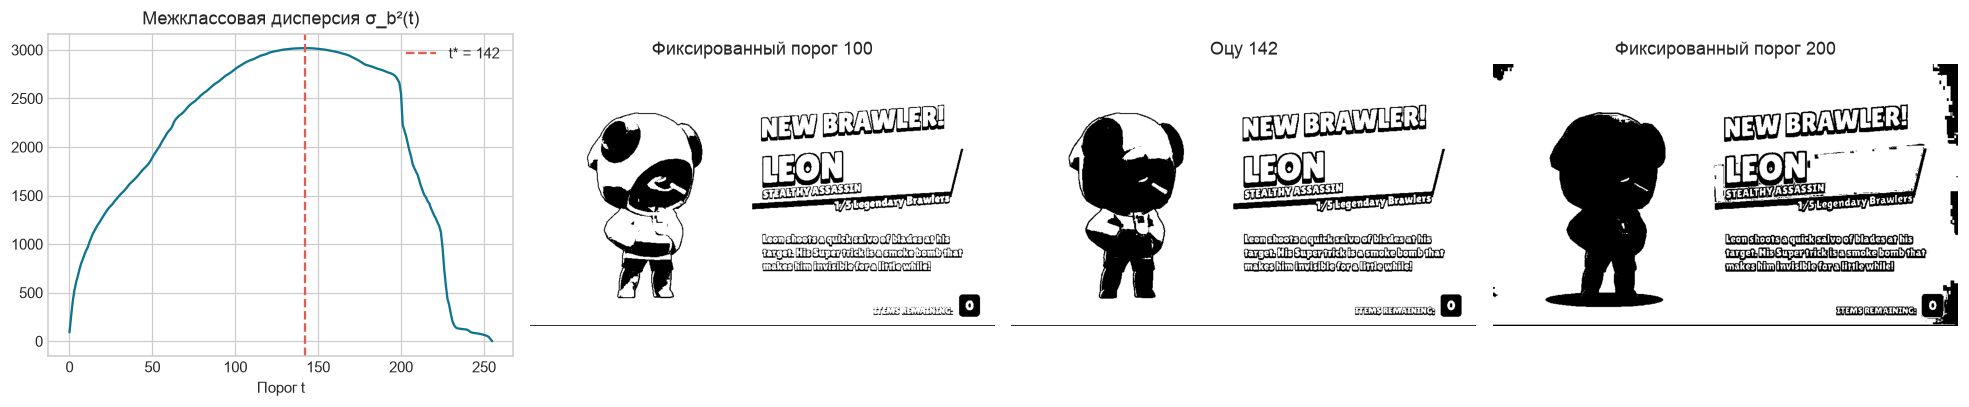

In [ ]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
p = hist / hist.sum()
levels = np.arange(256)

w0 = np.cumsum(p)
w1 = 1.0 - w0
mu_total = float((levels * p).sum())
mu0 = np.divide(np.cumsum(levels * p), w0, out=np.zeros(256), where=w0 > 0)
mu1 = np.divide(mu_total - np.cumsum(levels * p), w1, out=np.zeros(256), where=w1 > 0)
sigma_b = w0 * w1 * (mu0 - mu1) ** 2

manual_threshold = int(np.argmax(sigma_b))
print(f'Порог из OpenCV          : {otsu_threshold:.0f}')
print(f'Порог, посчитанный вручную: {manual_threshold}')
print(f'Максимум σ_b²            : {sigma_b.max():.1f}')

fixed_low, fixed_high = 100, 200
_, binary_low = cv2.threshold(gray, fixed_low, 255, cv2.THRESH_BINARY)
_, binary_high = cv2.threshold(gray, fixed_high, 255, cv2.THRESH_BINARY)

for label, mask in (('порог 100', binary_low), (f'Оцу {otsu_threshold:.0f}', binary), ('порог 200', binary_high)):
    print(f'{label:<12} доля белого = {(mask == 255).mean() * 100:5.2f}%')

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].plot(levels, sigma_b, color='#0e7490')
axes[0].axvline(manual_threshold, color='#e45c4f', linestyle='--', label=f't* = {manual_threshold}')
axes[0].set_title('Межклассовая дисперсия σ_b²(t)')
axes[0].set_xlabel('Порог t')
axes[0].legend()
axes[1].imshow(binary_low, cmap='gray'), axes[1].set_title(f'Фиксированный порог {fixed_low}')
axes[2].imshow(binary, cmap='gray'), axes[2].set_title(f'Оцу {otsu_threshold:.0f}')
axes[3].imshow(binary_high, cmap='gray'), axes[3].set_title(f'Фиксированный порог {fixed_high}')
for ax in axes[1:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

Канал      min   max   среднее   медиана   ст.откл.
B            0   255     49.70      33.0      49.32
G            0   255    218.46     251.0      66.31
R            0   255    208.49     240.0      75.01


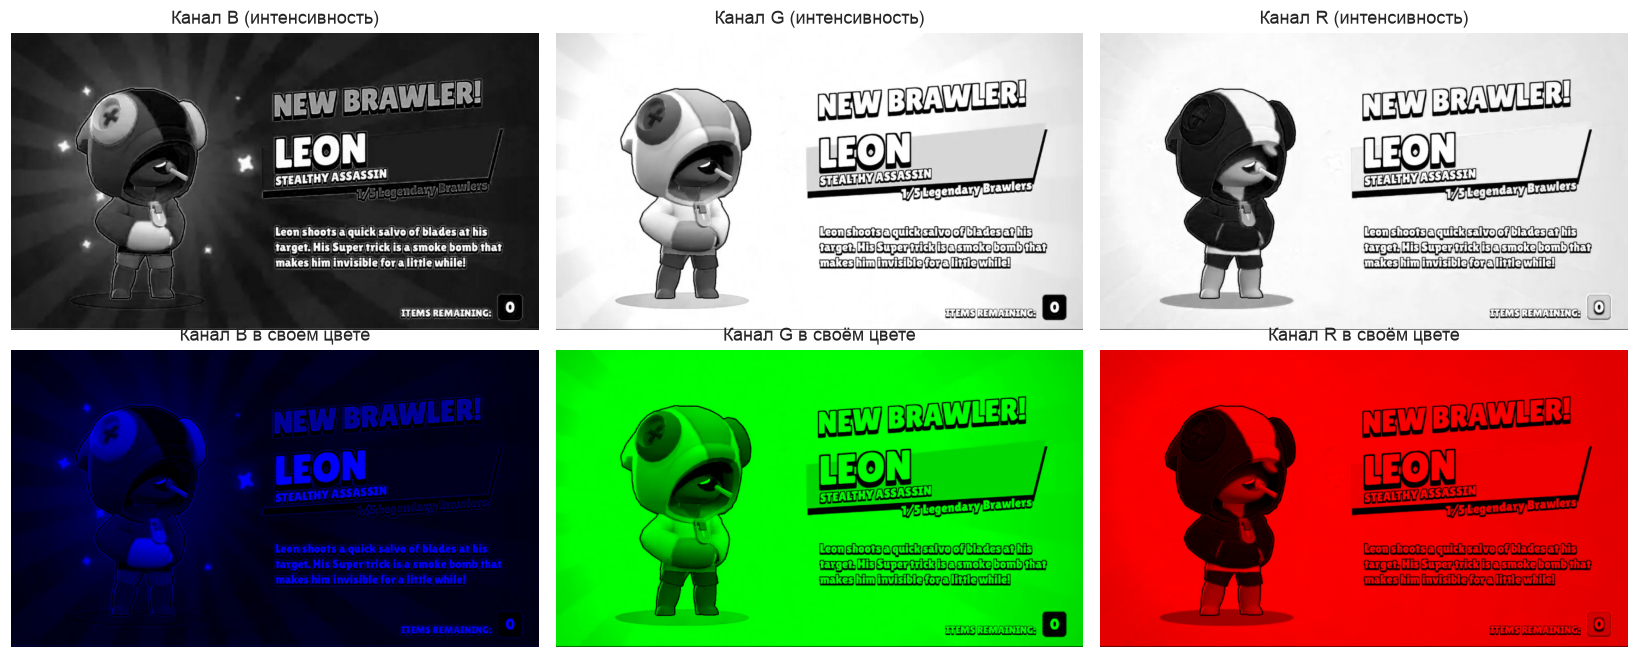


Каналы собраны обратно без потерь: True
Сохранено: output/channel_b.png, output/channel_g.png, output/channel_r.png


In [8]:
b, g, r = cv2.split(image)
zeros = np.zeros_like(b)

print(f'{"Канал":<8}{"min":>6}{"max":>6}{"среднее":>10}{"медиана":>10}{"ст.откл.":>11}')
for name, ch in (('B', b), ('G', g), ('R', r)):
    print(f'{name:<8}{ch.min():>6}{ch.max():>6}{ch.mean():>10.2f}{np.median(ch):>10.1f}{ch.std():>11.2f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for col, (name, ch, colored) in enumerate((
        ('B', b, cv2.merge([b, zeros, zeros])),
        ('G', g, cv2.merge([zeros, g, zeros])),
        ('R', r, cv2.merge([zeros, zeros, r])))):
    axes[0, col].imshow(ch, cmap='gray')
    axes[0, col].set_title(f'Канал {name} (интенсивность)')
    axes[1, col].imshow(cv2.cvtColor(colored, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'Канал {name} в своём цвете')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

for name, ch in (('b', b), ('g', g), ('r', r)):
    cv2.imwrite(str(OUTPUT_DIR / f'channel_{name}.png'), ch)

restored = cv2.merge([b, g, r])
print(f'\nКаналы собраны обратно без потерь: {np.array_equal(restored, image)}')
print('Сохранено: output/channel_b.png, output/channel_g.png, output/channel_r.png')

Доминирующий тон H = 31 (в градусах ≈ 62°), 216264 пикселей
Доля пикселей жёлтого фона: 78.16%


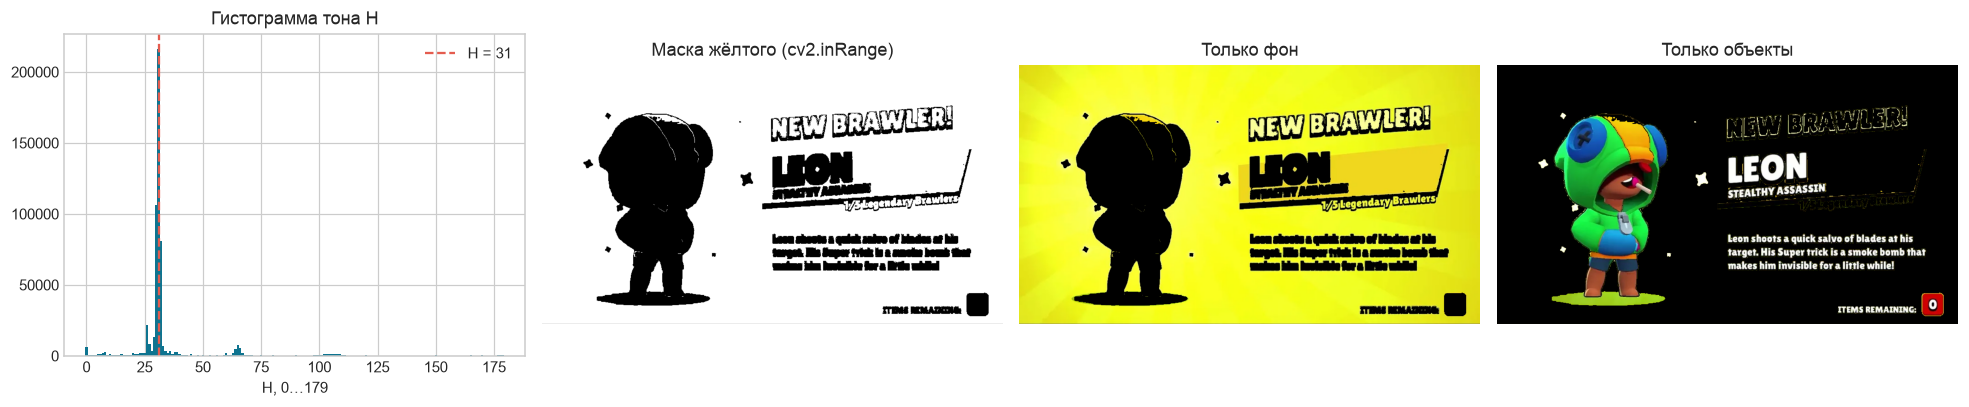

In [ ]:
hue_hist = cv2.calcHist([hsv], [0], None, [180], [0, 180]).ravel()
dominant_hue = int(np.argmax(hue_hist))
print(f'Доминирующий тон H = {dominant_hue} (в градусах ≈ {dominant_hue * 2}°), '
      f'{int(hue_hist[dominant_hue])} пикселей')

YELLOW_LOW = np.array([26, 80, 80])
YELLOW_HIGH = np.array([35, 255, 255])
yellow_mask = cv2.inRange(hsv, YELLOW_LOW, YELLOW_HIGH)
print(f'Доля пикселей жёлтого фона: {(yellow_mask > 0).mean() * 100:.2f}%')

background = cv2.bitwise_and(image, image, mask=yellow_mask)
foreground = cv2.bitwise_and(image, image, mask=cv2.bitwise_not(yellow_mask))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].bar(np.arange(180), hue_hist, color='#0e7490', width=1.0)
axes[0].axvline(dominant_hue, color='#e45c4f', linestyle='--', label=f'H = {dominant_hue}')
axes[0].set_title('Гистограмма тона H')
axes[0].set_xlabel('H, 0…179')
axes[0].legend()
axes[1].imshow(yellow_mask, cmap='gray'), axes[1].set_title('Маска жёлтого (cv2.inRange)')
axes[2].imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB)), axes[2].set_title('Только фон')
axes[3].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB)), axes[3].set_title('Только объекты')
for ax in axes[1:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

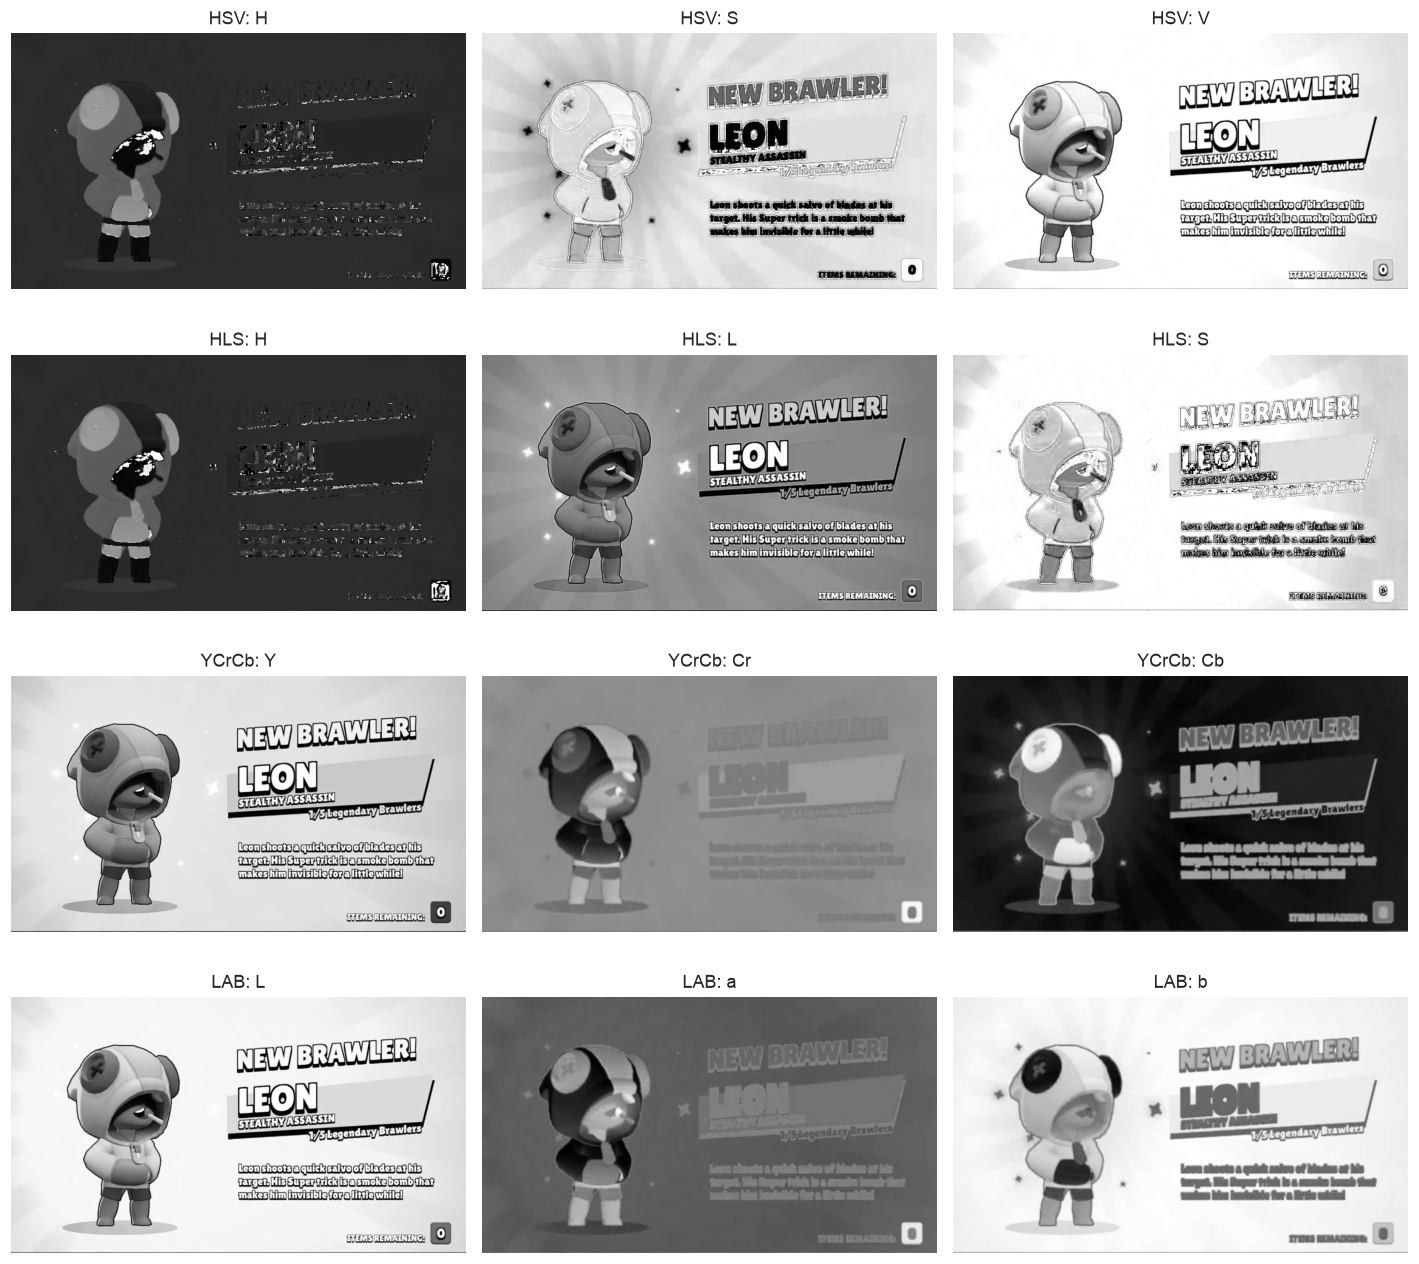

Максимальная разница |Y − gray| : 1
Средняя разница                 : 0.0035
Доля полностью совпавших пикселей: 99.65%

Вывод: канал Y модели YCrCb и полутоновое изображение — это одна и та же величина,
расхождения возникают только из-за округления при целочисленных вычислениях.


In [10]:
models = {
    'HSV':   (cv2.cvtColor(image, cv2.COLOR_BGR2HSV),   ('H', 'S', 'V')),
    'HLS':   (cv2.cvtColor(image, cv2.COLOR_BGR2HLS),   ('H', 'L', 'S')),
    'YCrCb': (cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb), ('Y', 'Cr', 'Cb')),
    'LAB':   (cv2.cvtColor(image, cv2.COLOR_BGR2LAB),   ('L', 'a', 'b')),
}

fig, axes = plt.subplots(4, 3, figsize=(13, 12))
for row, (model, (converted, names)) in enumerate(models.items()):
    for col, ch_name in enumerate(names):
        axes[row, col].imshow(converted[:, :, col], cmap='gray')
        axes[row, col].set_title(f'{model}: {ch_name}')
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

y_channel = models['YCrCb'][0][:, :, 0]
difference = cv2.absdiff(y_channel, gray)
print(f'Максимальная разница |Y − gray| : {difference.max()}')
print(f'Средняя разница                 : {difference.mean():.4f}')
print(f'Доля полностью совпавших пикселей: {(difference == 0).mean() * 100:.2f}%')
print('\nВывод: канал Y модели YCrCb и полутоновое изображение — это одна и та же величина,')
print('расхождения возникают только из-за округления при целочисленных вычислениях.')

Изменение яркости: +30
Сохранено: output/brightened.png
Диапазон исходного изображения: 0…255
Диапазон после изменения: 30…255


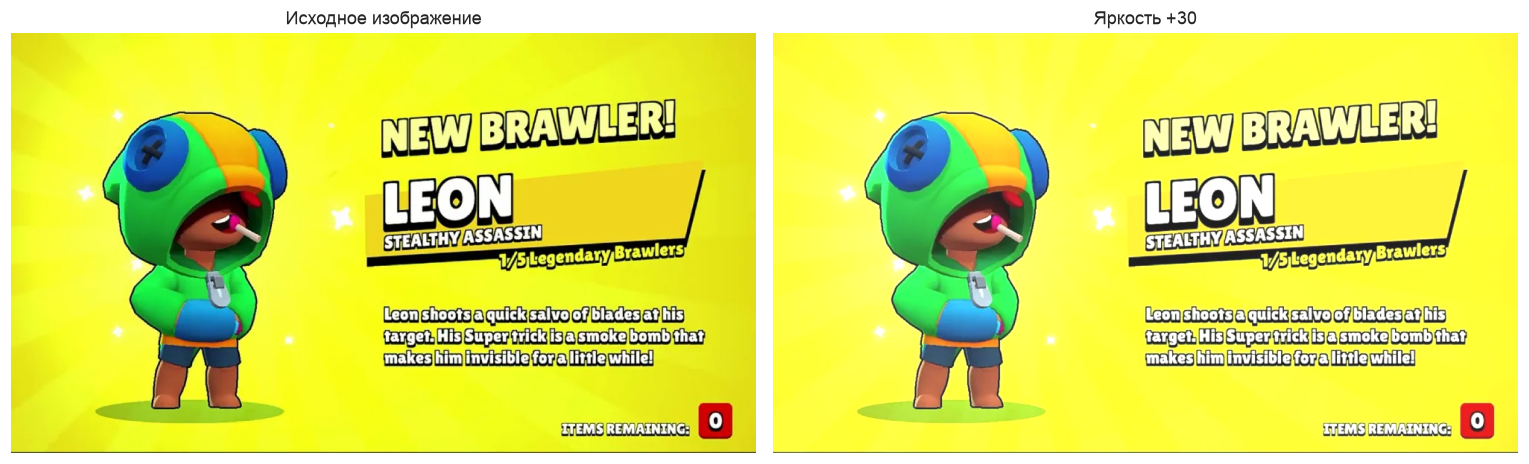

In [11]:
BRIGHTNESS_SHIFT = 30
brightened = cv2.convertScaleAbs(image, alpha=1.0, beta=BRIGHTNESS_SHIFT)

brightened_path = OUTPUT_DIR / 'brightened.png'
cv2.imwrite(str(brightened_path), brightened)

print(f'Изменение яркости: +{BRIGHTNESS_SHIFT}')
print(f'Сохранено: {brightened_path}')
print(f'Диапазон исходного изображения: {image.min()}…{image.max()}')
print(f'Диапазон после изменения: {brightened.min()}…{brightened.max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].imshow(image_rgb)
axes[0].set_title('Исходное изображение')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(brightened, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Яркость +{BRIGHTNESS_SHIFT}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [12]:
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f'{path.name:<24} {path.stat().st_size / 1024:8.1f} КБ')

brightened.png              428.4 КБ
channel_b.png               197.7 КБ
channel_g.png               165.9 КБ
channel_r.png               179.8 КБ
edited_blue_edge.png        514.4 КБ
gray.png                    166.8 КБ
hsv_h.png                    94.8 КБ
hsv_s.png                   198.5 КБ
hsv_v.png                   168.0 КБ
otsu_binary.png              17.0 КБ
sticker_rgba.png            571.9 КБ


## Ответы на контрольные вопросы

**1. Что такое пиксель и как он представлен в цветном изображении?**
Пиксель — наименьший элемент растрового изображения. В цветном изображении он представлен вектором из трёх чисел uint8, в OpenCV — в порядке B, G, R. Обращение image[y, x] возвращает именно такой вектор; в этой работе центральный пиксель изображения имеет значение, выведенное в разделе 1.

**2. В чём разница между RGB и HSV?**
RGB задаёт цвет через смесь трёх первичных излучений и удобен для вывода на экран, но информация о «самом цвете» размазана по всем трём каналам: при смене освещения меняются все три значения. HSV разделяет цвет и яркость — тон H отвечает за оттенок, S за насыщенность, V за яркость. Поэтому выделять объекты по цвету (как жёлтый фон в задаче 8) удобнее в HSV: достаточно ограничить один канал H. В OpenCV H хранится в диапазоне 0–179, чтобы поместиться в один байт.

**3. Как получить отдельный цветовой канал в OpenCV?**
Двумя способами: b, g, r = cv2.split(image) — разбивает массив на три отдельных, или срезом NumPy image[:, :, 0] — быстрее, так как не копирует данные. Обратная сборка — cv2.merge([b, g, r]); в задаче 7 проверено, что она восстанавливает исходный массив бит в бит.

**4. Как преобразовать цветное изображение в градации серого?**
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY). Внутри считается взвешенная сумма $Y = 0.299R + 0.587G + 0.114B$. Альтернатива — сразу прочитать файл флагом cv2.IMREAD_GRAYSCALE. В задаче 9 показано, что результат совпадает с каналом Y модели YCrCb.

**5. Что такое альфа-канал?**
Четвёртый канал изображения, задающий непрозрачность каждого пикселя: 0 — полностью прозрачный, 255 — полностью непрозрачный. При наложении изображения на фон используется формула $C = \alpha F + (1-\alpha) B$. Альфа-канал поддерживают PNG и TIFF, но не JPEG. В OpenCV читать его нужно с флагом cv2.IMREAD_UNCHANGED — обычный cv2.imread возвращает только три канала, что и продемонстрировано в задаче 10.